## DATASET DESCRIPTION:

The Telco Customer Churn dataset contains information about customers of a fictional telecommunications company.The main objective is to predict whether a customer is likely to leave (churn) the telecom company based on their demographic information, subscribed services, contract details, and billing information.

##### Target Variable :  Churn (with the categories yes/no)
The dataset has substantially more non-churned customers than churned customers, making class imbalance analysis relevant for our project.

There are 20 input features covering demographic information , account information and services used by the customer.

Dimension of the dataset: 7043 rows × 21 columns.

### Dataset loading & audit 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

The dataset is loaded from csv file into dataframe

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Though it shows that there are no null values but there are null values present in the form of NaN which are handled during preprocessing

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### EDA Visualizations

Distribution of Numerical features

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Features:")
print(numerical_cols.tolist())

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


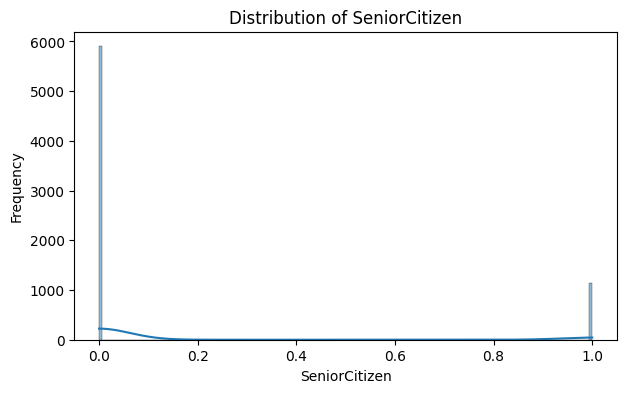

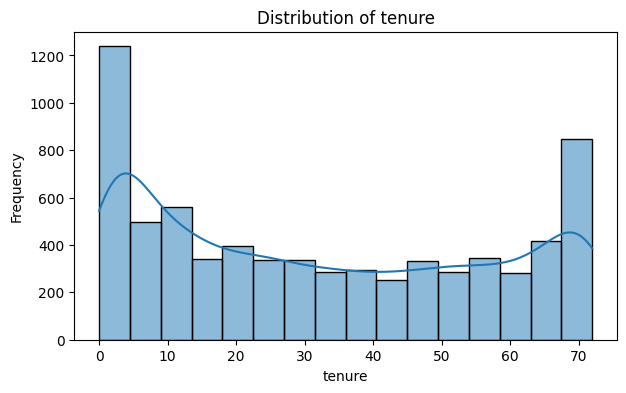

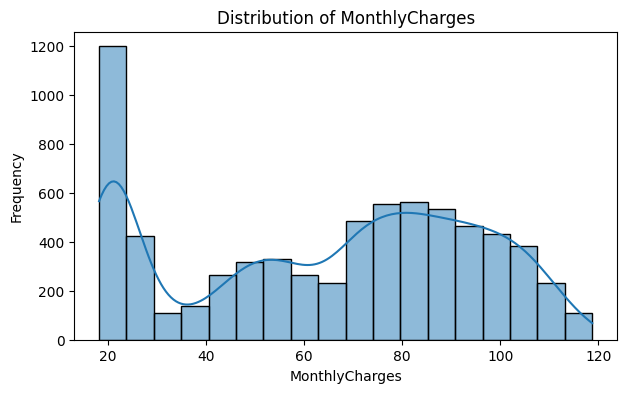

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

##### Categorical Features

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical_cols.tolist())

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


Drop customerID because its just an identifier which doesnt provide any useful information

In [15]:
categorical_cols = categorical_cols.drop('customerID')

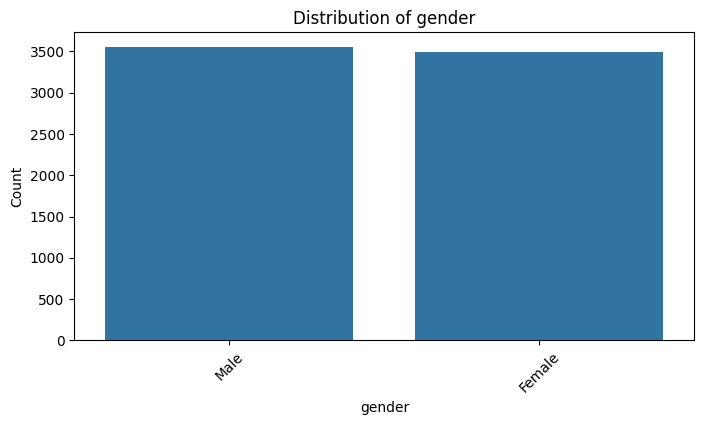

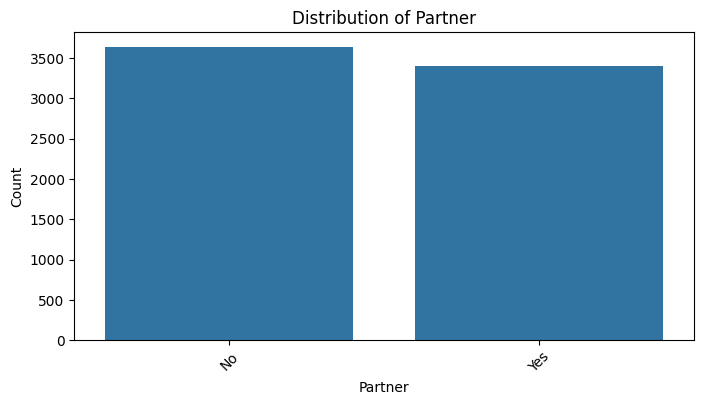

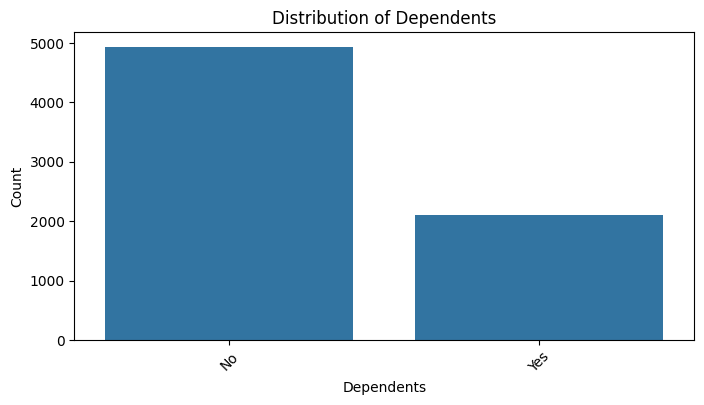

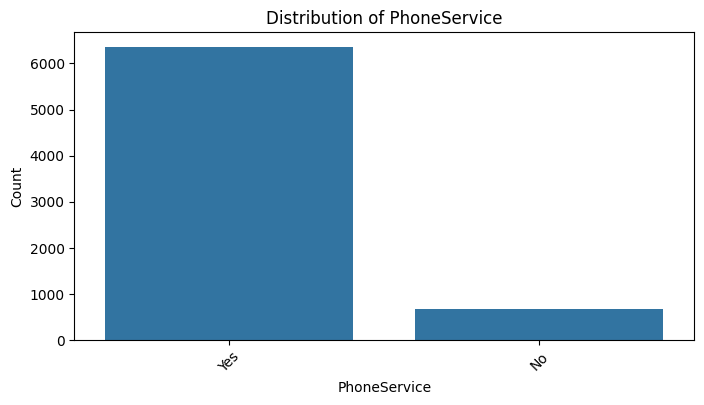

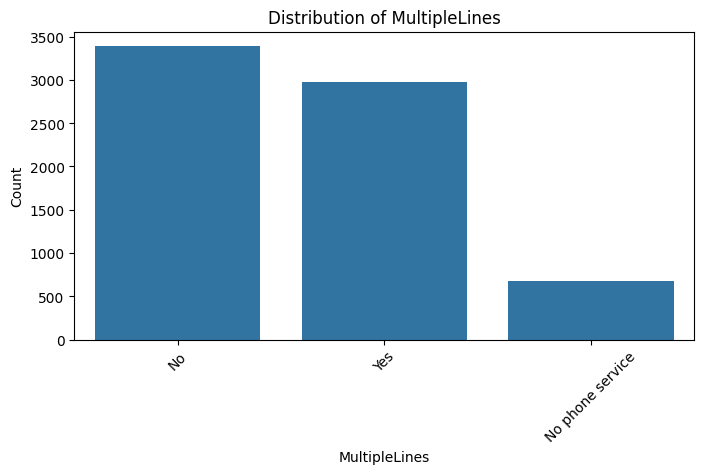

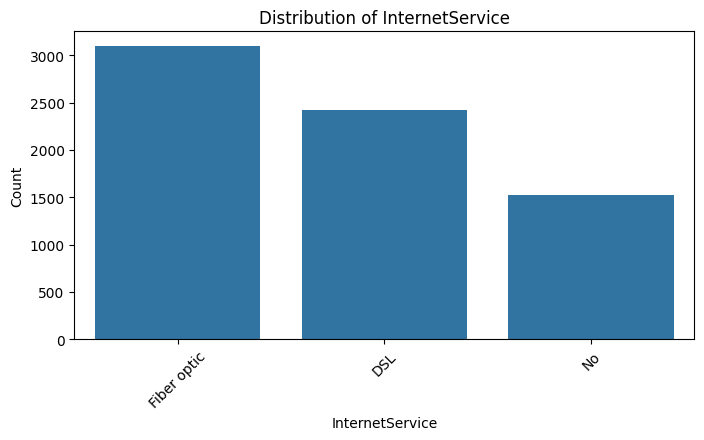

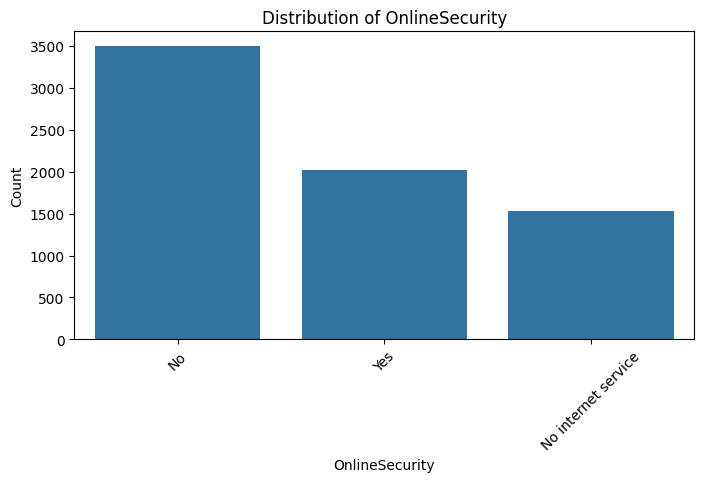

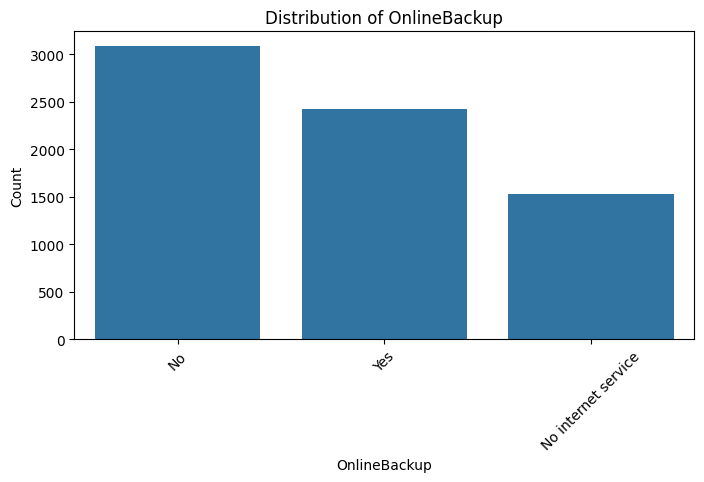

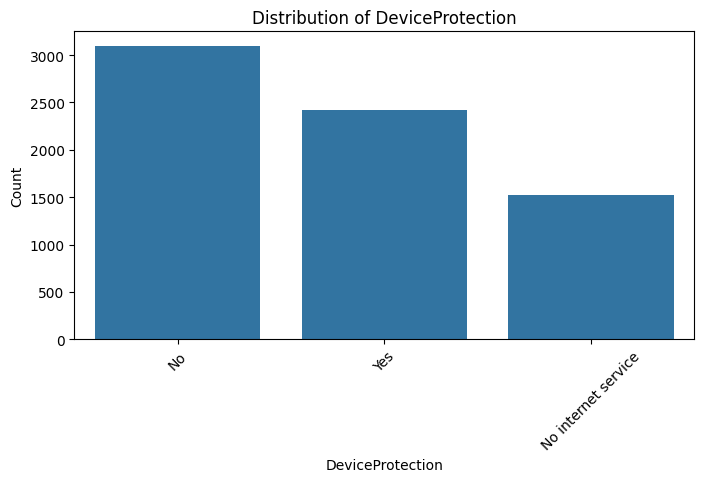

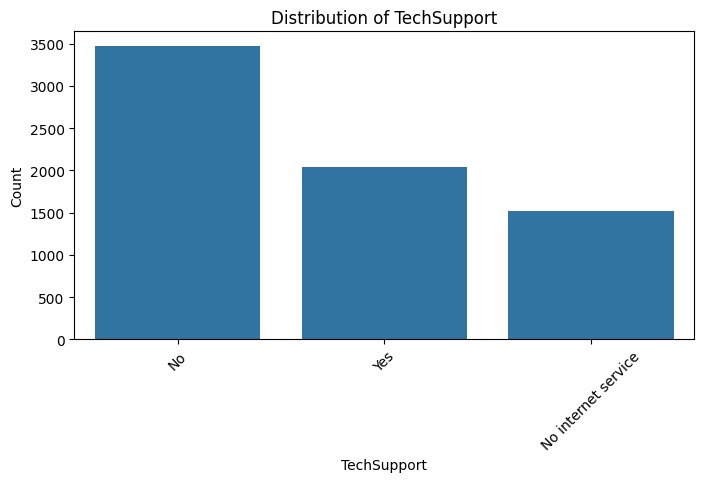

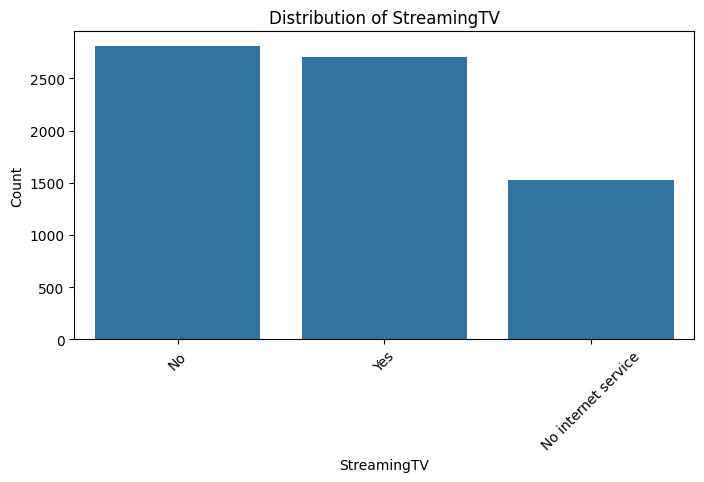

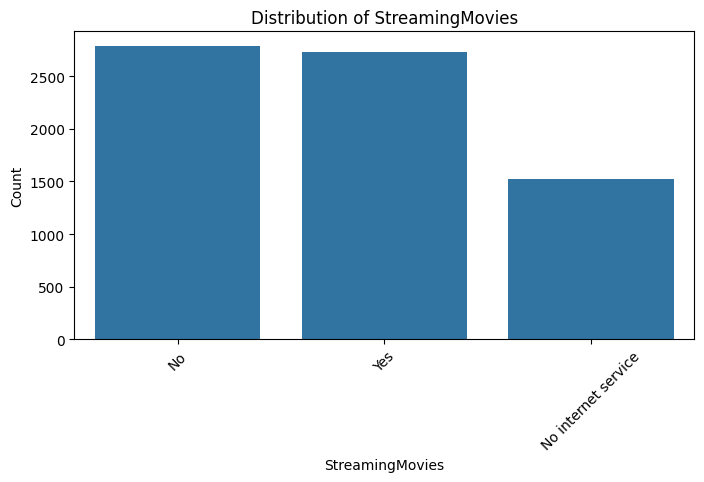

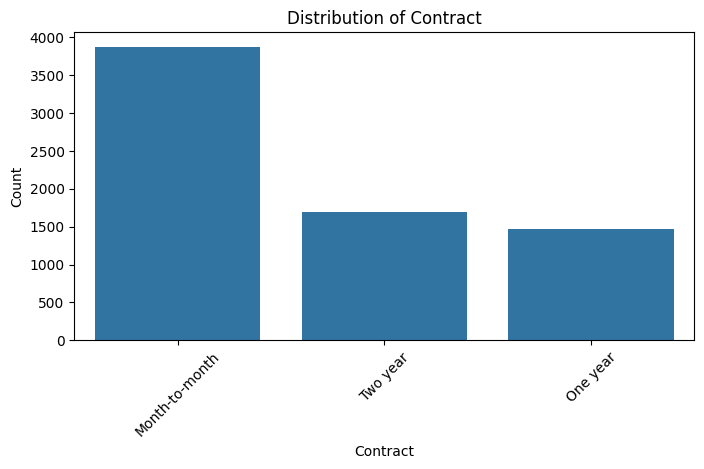

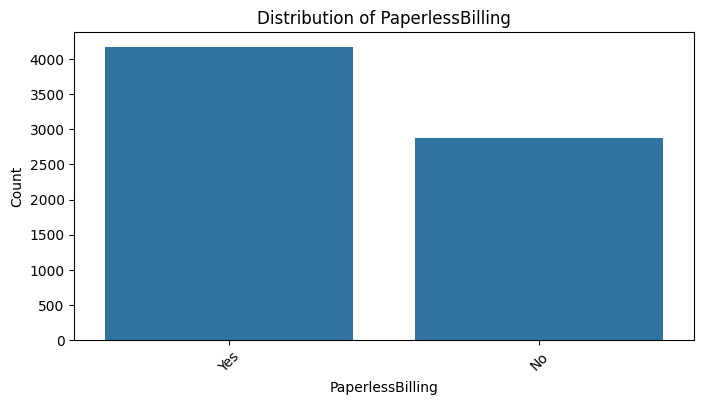

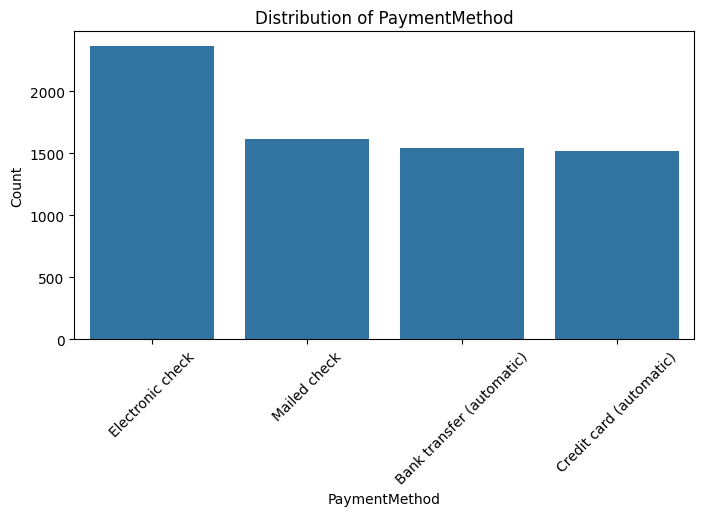

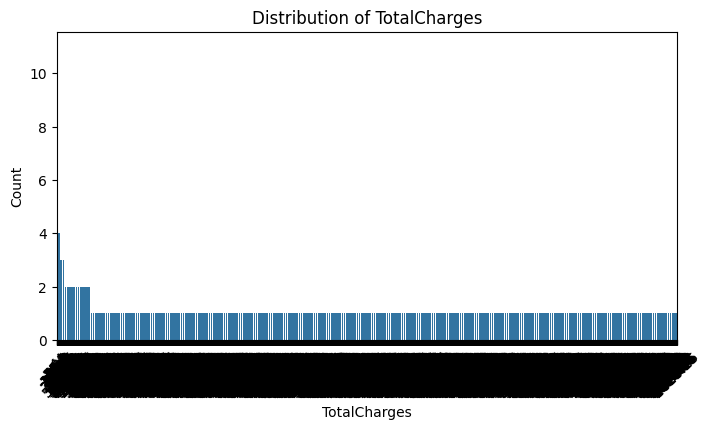

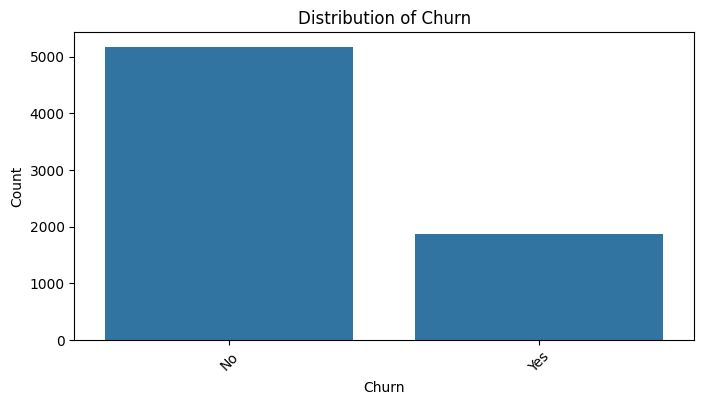

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

##### Distribution of target variable

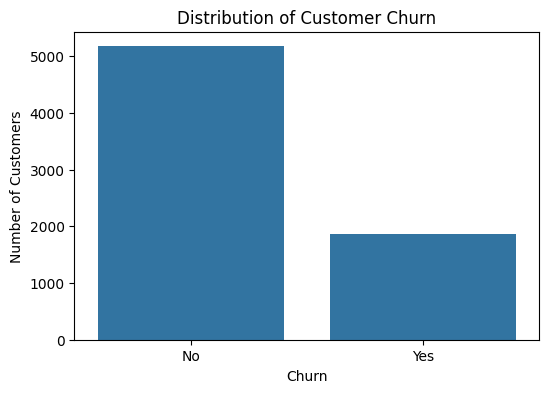

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Observation: The target variable is imbalanced, with a higher proportion of customers who did not churn compared to customers who churned. Therefore, accuracy alone may not be sufficient for evaluating the classification models. Precision, Recall, F1-score and ROC-AUC will also be considered.

#### Correlation HeatMap

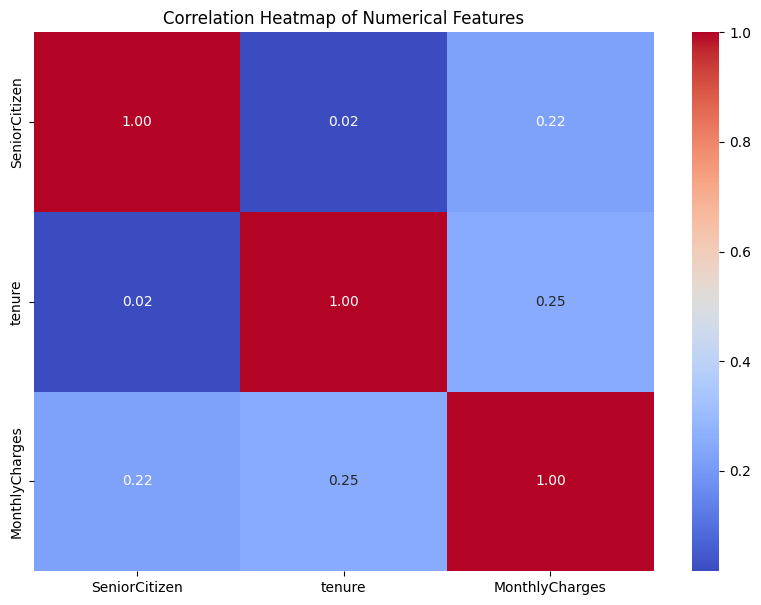

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

1)The heatmap shows a strong positive correlation between tenure and TotalCharges, since customers who stay longer generally accumulate higher total charges.

2)MonthlyCharges also has a positive relationship with TotalCharges, while the correlation between tenure and MonthlyCharges is relatively weak.These relationships are expected because TotalCharges depends largely on the duration of service and the monthly amount paid.

##### Feature-Target RelationShip 

1)Tenure vs Churn

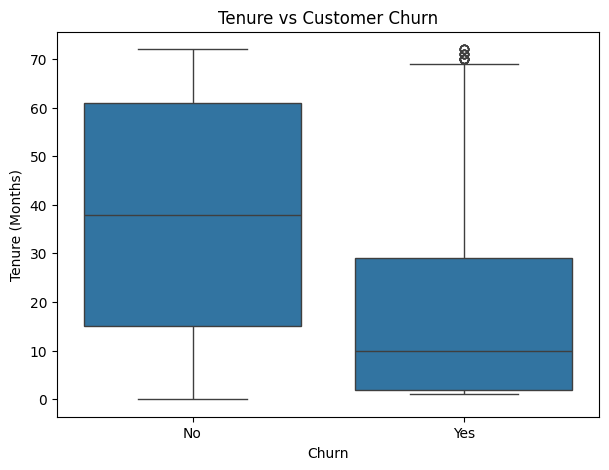

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

Customers who churn generally have lower tenure than customers who stay, indicating that newer customers are more prone to churn

2)Monthly Charges vs Churn


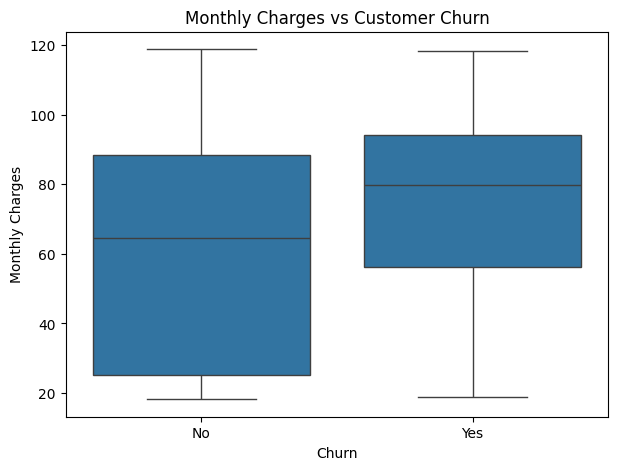

In [20]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Churned customers generally show higher monthly charges, suggesting that monthly cost may be associated with churn.

In [21]:
# Create a copy of the original dataset for preprocessing
data = df.copy()

print("Original shape:", data.shape)

Original shape: (7043, 21)


##### Data Cleaning
A copy of the original dataset is created so that the raw data remains unchanged.
The preprocessing steps will be performed on the copied dataset.

In [22]:
# Check for duplicate rows
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0



No duplicate records were found in the dataset. Therefore, no rows were removed due to duplication.

In [23]:
# Convert TotalCharges from object/string to numeric
data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'],
    errors='coerce'
)

# Check missing values
print("Missing values in TotalCharges:", data['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [24]:
# Remove rows with missing TotalCharges
data = data.dropna(subset=['TotalCharges'])

print("Shape after handling missing values:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())

Shape after handling missing values: (7032, 21)
Remaining missing values: 0


##### Handling Missing Values
The `TotalCharges` column was initially stored as an object because some records contained blank values instead of numeric values. These invalid entries were converted to `NaN` using `pd.to_numeric()` with `errors='coerce'`.

Only 11 records contain missing `TotalCharges` values out of 7,043 records, representing approximately 0.16% of the dataset. Since the number of affected records is extremely small, these rows are removed rather than imputing potentially inaccurate total billing amounts.

This ensures that the `TotalCharges` feature contains valid numerical values before modelling.

In [25]:
data = data.drop(columns=['customerID'])

##### Removing the Identifier
The `customerID` column is a unique identifier for each customer and does not contain meaningful behavioural or demographic information for predicting churn. Including it could introduce noise without providing useful predictive information.

Therefore, `customerID` is removed before model training.

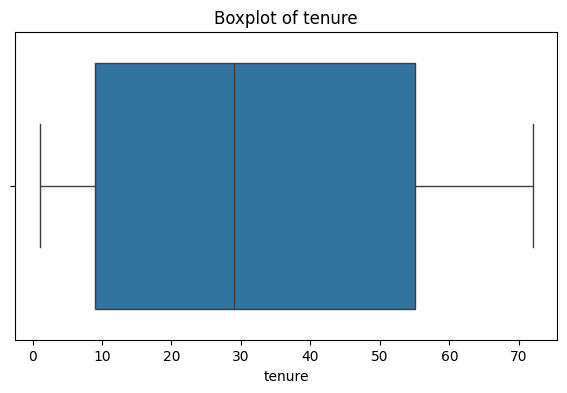

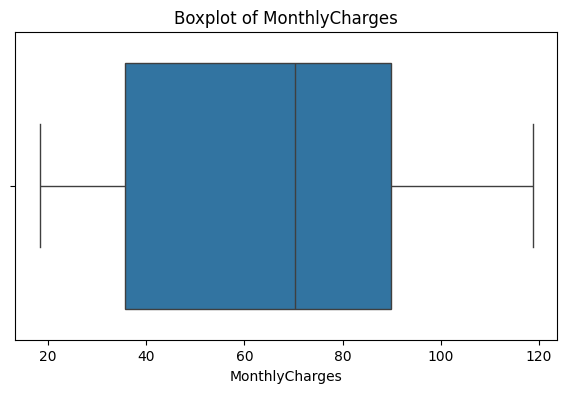

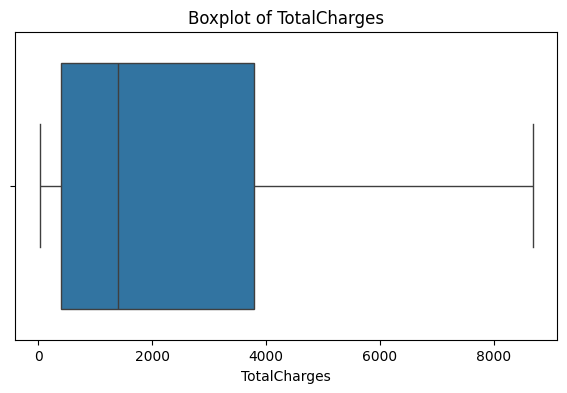

In [26]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

##### Outlier Detection
Boxplots were used to identify potential outliers in the continuous numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`.

Potential extreme observations were identified based on the interquartile range (IQR) method. However, extreme values in this dataset can represent genuine customers with high charges or long service durations rather than data-entry errors. Therefore, instead of deleting these observations, an IQR-based capping strategy is used to reduce the influence of extreme values while retaining the corresponding customer records.

In [27]:
# Separate features and target
X = data.drop(columns=['Churn'])
y = data['Churn'].map({'No': 0, 'Yes': 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7032, 19)
Target shape: (7032,)


##### Target Encoding
The target variable `Churn` contains two categories: `No` and `Yes`.
Since machine learning algorithms require numerical target values, the target is encoded as:

- `No` → 0
- `Yes` → 1

The positive class (`1`) therefore represents customers who churned.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (5625, 19)
Testing set: (1407, 19)

Training target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


##### Train-Test Split

The dataset is divided into 80% training data and 20% testing data using `random_state=42` for reproducibility.

Stratification is applied using the target variable so that the proportion of churned and non-churned customers remains approximately the same in both the training and testing sets.

The test set is kept completely separate and will only be used for final model evaluation.

In [29]:
# IQR-based outlier capping using training data only

outlier_bounds = {}

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_bounds[col] = (lower_bound, upper_bound)
    
    print(f"{col}:")
    print(f"Lower bound = {lower_bound:.2f}")
    print(f"Upper bound = {upper_bound:.2f}")
    print()

tenure:
Lower bound = -61.50
Upper bound = 126.50

MonthlyCharges:
Lower bound = -45.58
Upper bound = 171.43

TotalCharges:
Lower bound = -4670.05
Upper bound = 8884.75



In [30]:
# Apply training-derived outlier bounds
for col, (lower, upper) in outlier_bounds.items():
    X_train[col] = X_train[col].clip(lower=lower, upper=upper)
    X_test[col] = X_test[col].clip(lower=lower, upper=upper)

### Outlier Treatment

The IQR method was used to determine the lower and upper bounds for continuous numerical variables.

The bounds were calculated using only the training data to prevent information leakage from the test set. Instead of deleting observations, values outside the calculated bounds were capped at the respective limits.

This approach retains all customer records while reducing the influence of extreme numerical values on models that are sensitive to feature scale and extreme observations.

In [31]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for dataset in [X_train, X_test]:
    dataset['TotalServices'] = (
        dataset[service_cols]
        .apply(lambda row: (row == 'Yes').sum(), axis=1)
    )

print(X_train[['TotalServices']].head())
print(X_train['TotalServices'].describe())

      TotalServices
1413              6
7003              2
3355              5
4494              3
3541              2
count    5625.00000
mean        3.38400
std         2.06011
min         0.00000
25%         1.00000
50%         3.00000
75%         5.00000
max         8.00000
Name: TotalServices, dtype: float64


### Feature Engineering

### Engineered Feature: TotalServices

A new feature called `TotalServices` is created by counting the number of services subscribed to by each customer.

The original dataset contains several separate service-related variables such as phone service, online security, online backup, device protection, technical support, and streaming services. Combining these variables into a single feature provides an overall measure of the customer's level of service engagement.

Customers with a greater number of subscribed services may have different churn behaviour compared with customers using fewer services. Therefore, `TotalServices` may provide additional predictive information and potentially improve model performance.

In [32]:
categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features)
    ]
)

### Encoding and Scaling

The categorical features are converted into numerical form using One-Hot Encoding. This creates separate binary columns for the different categories without introducing an artificial ordering between categories.

`handle_unknown='ignore'` is used so that an unseen category in the test set does not cause an error.

The numerical features are standardized using `StandardScaler`, which transforms the features to have approximately zero mean and unit variance.

Scaling is particularly important for distance- and gradient-based algorithms such as KNN, SVC, and MLP. Tree-based algorithms are less sensitive to feature scaling, but using a consistent preprocessing pipeline allows the same transformed dataset to be used fairly across the required models.

The scaler and encoder will be fitted only on the training data to prevent data leakage.

In [34]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5625, 46)
Processed testing shape: (1407, 46)


In [35]:

print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Missing values in processed training data: 0
Missing values in processed testing data: 0


## Classification Track – Part A

Five classification algorithms are implemented and evaluated:
- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Decision Tree Classifier
- Support Vector Classifier (SVC)

Each model is trained on the preprocessed training data and evaluated on the held-out test data using Accuracy, Weighted F1-score, and Confusion Matrix.

## 1. Logistic Regression

Logistic Regression is used as the baseline classification algorithm. It models the probability that a customer belongs to a particular class, in this case whether the customer will churn or not.

The model is trained using the preprocessed training features and corresponding target values. Predictions are then generated for the held-out test dataset.

In [36]:
from sklearn.linear_model import LogisticRegression
classification_results = []

In [37]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
logistic_model.fit(X_train_processed, y_train)
y_pred_logistic = logistic_model.predict(X_test_processed)
y_pred_logistic[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

##### Accuracy

Accuracy measures the proportion of test samples that were classified correctly.

In [38]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.8053


##### Weighted F1-score

The weighted F1-score combines precision and recall for each class and calculates their average weighted by the number of samples in each class.

It is useful for this dataset because the churn classes are imbalanced.

In [39]:
from sklearn.metrics import f1_score

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

print(f"Logistic Regression Weighted F1-score: {logistic_f1:.4f}")

Logistic Regression Weighted F1-score: 0.8014


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(logistic_cm)

Confusion Matrix:
[[917 116]
 [158 216]]


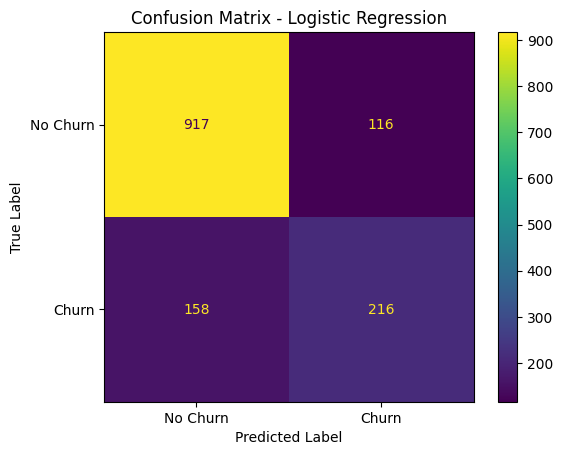

In [41]:
logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["No Churn", "Churn"]
)

logistic_display.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [42]:
classification_results.append({
    "Algorithm": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Weighted F1": logistic_f1
})


### Observation – Logistic Regression

Logistic Regression was trained on the preprocessed training dataset and evaluated on the held-out test dataset. The model achieved an accuracy of 0.8053 and a weighted F1-score of  0.8014.

The confusion matrix shows the number of correctly and incorrectly classified churn and non-churn customers. The results provide a baseline against which the other classification algorithms can be compared.

## 2. K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based classification algorithm. It classifies a new observation based on the classes of its nearest neighboring observations.

For the baseline implementation, k is set to 5. Since KNN relies on distance calculations, feature scaling is important. The numerical features in this dataset have already been standardized during preprocessing.

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
y_pred_knn = knn_model.predict(X_test_processed)
y_pred_knn[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

##### Accuracy

In [44]:
from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.7619


##### Weighted F1-score

In [45]:
from sklearn.metrics import f1_score

knn_f1 = f1_score(
    y_test,
    y_pred_knn,
    average='weighted'
)

print(f"KNN Weighted F1-score: {knn_f1:.4f}")

KNN Weighted F1-score: 0.7634


##### Confusion matrix

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print("Confusion Matrix:")
print(knn_cm)

Confusion Matrix:
[[858 175]
 [160 214]]


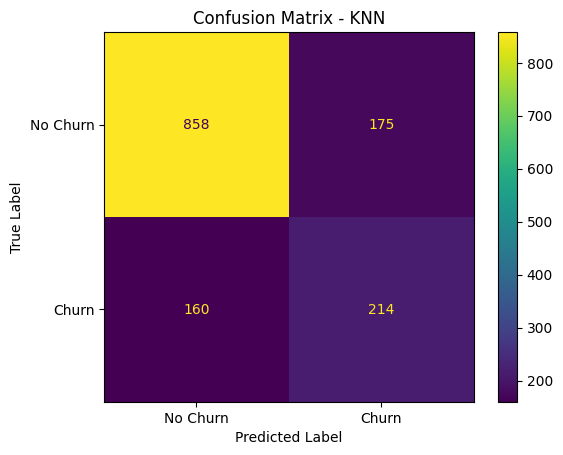

In [47]:
knn_display = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=["No Churn", "Churn"]
)

knn_display.plot()

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [48]:
classification_results.append({
    "Algorithm": "K-Nearest Neighbors",
    "Accuracy": knn_accuracy,
    "Weighted F1": knn_f1
})

### Observation – K-Nearest Neighbors

The KNN classifier was trained using k = 5 and evaluated on the held-out test dataset. The model achieved an accuracy of 0.7612 and a weighted F1-score of 0.7626.

The confusion matrix shows the correctly and incorrectly classified churn and non-churn customers. Since KNN is a distance-based algorithm, the scaling of numerical features is important for obtaining meaningful distance calculations.

## 3. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. It assumes that the features are conditionally independent given the target class.

The Gaussian version assumes that the continuous numerical features follow a Gaussian (normal) distribution within each class.

The model is trained on the preprocessed training data and used to predict customer churn on the held-out test data.

In [49]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_processed, y_train)

y_pred_nb = nb_model.predict(X_test_processed)
y_pred_nb[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

##### Accuracy

In [50]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print(f"Gaussian Naive Bayes Accuracy: {nb_accuracy:.4f}")

Gaussian Naive Bayes Accuracy: 0.6837


##### Weighted F1 score

In [51]:
from sklearn.metrics import f1_score

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

print(f"Gaussian Naive Bayes Weighted F1-score: {nb_f1:.4f}")

Gaussian Naive Bayes Weighted F1-score: 0.7021


##### Confusion Matrix

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nb_cm = confusion_matrix(
    y_test,
    y_pred_nb
)

print("Confusion Matrix:")
print(nb_cm)

Confusion Matrix:
[[652 381]
 [ 64 310]]


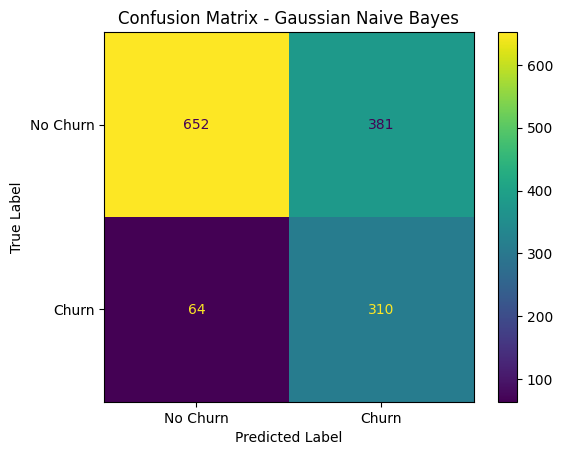

In [53]:
nb_display = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["No Churn", "Churn"]
)

nb_display.plot()

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Conditional Independence Assumption

Gaussian Naive Bayes assumes that the input features are **conditionally independent given the target class**.

For the Telco Customer Churn dataset, this means that features such as **tenure, MonthlyCharges, TotalCharges, Contract, and subscribed services** are treated as independent when calculating the probability of churn.

In practice, this assumption may not hold completely because some customer attributes can be related to each other. For example, **tenure and TotalCharges** are likely to be related. Nevertheless, Gaussian Naive Bayes provides a useful probabilistic baseline for comparison with other classification algorithms.

In [54]:
classification_results.append({
    "Algorithm": "Gaussian Naive Bayes",
    "Accuracy": nb_accuracy,
    "Weighted F1": nb_f1
})


### Observation – Gaussian Naive Bayes

Gaussian Naive Bayes was trained and evaluated on the same training and test datasets used for the other Part-A algorithms. The model achieved an accuracy of 0.6837 and a weighted F1-score of 0.7021.

The confusion matrix shows the correct and incorrect predictions for churn and non-churn customers.

The model assumes conditional independence among the input features given the target class. This assumption may not hold completely for the Telco Customer Churn dataset because several customer attributes can be related to each other. Nevertheless, Gaussian Naive Bayes provides a useful probabilistic baseline for comparison with the other classification algorithms.

## 4. Decision Tree Classifier

A Decision Tree Classifier is a tree-based supervised learning algorithm that makes predictions by recursively splitting the dataset based on feature values.

Each internal node represents a decision based on a feature, each branch represents an outcome of that decision, and each leaf node represents the predicted class.

For the baseline model, the default decision tree configuration is used. Hyperparameter tuning, including tuning `max_depth`, will be performed later.

In [55]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train_processed, y_train)
y_pred_dt = dt_model.predict(X_test_processed)
y_pred_dt[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

##### Accuracy

In [56]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7392


##### Weighted F1 score

In [57]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print(f"Decision Tree Weighted F1-score: {dt_f1:.4f}")

Decision Tree Weighted F1-score: 0.7406


##### Confusion Matrix

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dt_cm = confusion_matrix(
    y_test,
    y_pred_dt
)

print("Confusion Matrix:")
print(dt_cm)

Confusion Matrix:
[[843 190]
 [177 197]]


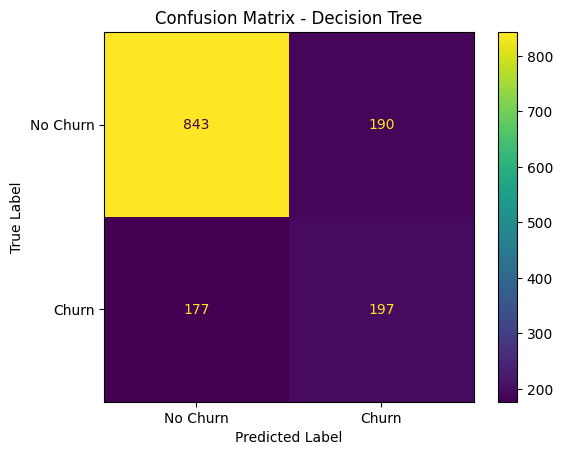

In [59]:
dt_display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["No Churn", "Churn"]
)

dt_display.plot()

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [60]:
classification_results.append({
    "Algorithm": "Decision Tree Classifier",
    "Accuracy": dt_accuracy,
    "Weighted F1": dt_f1
})

##### Tree Visualization

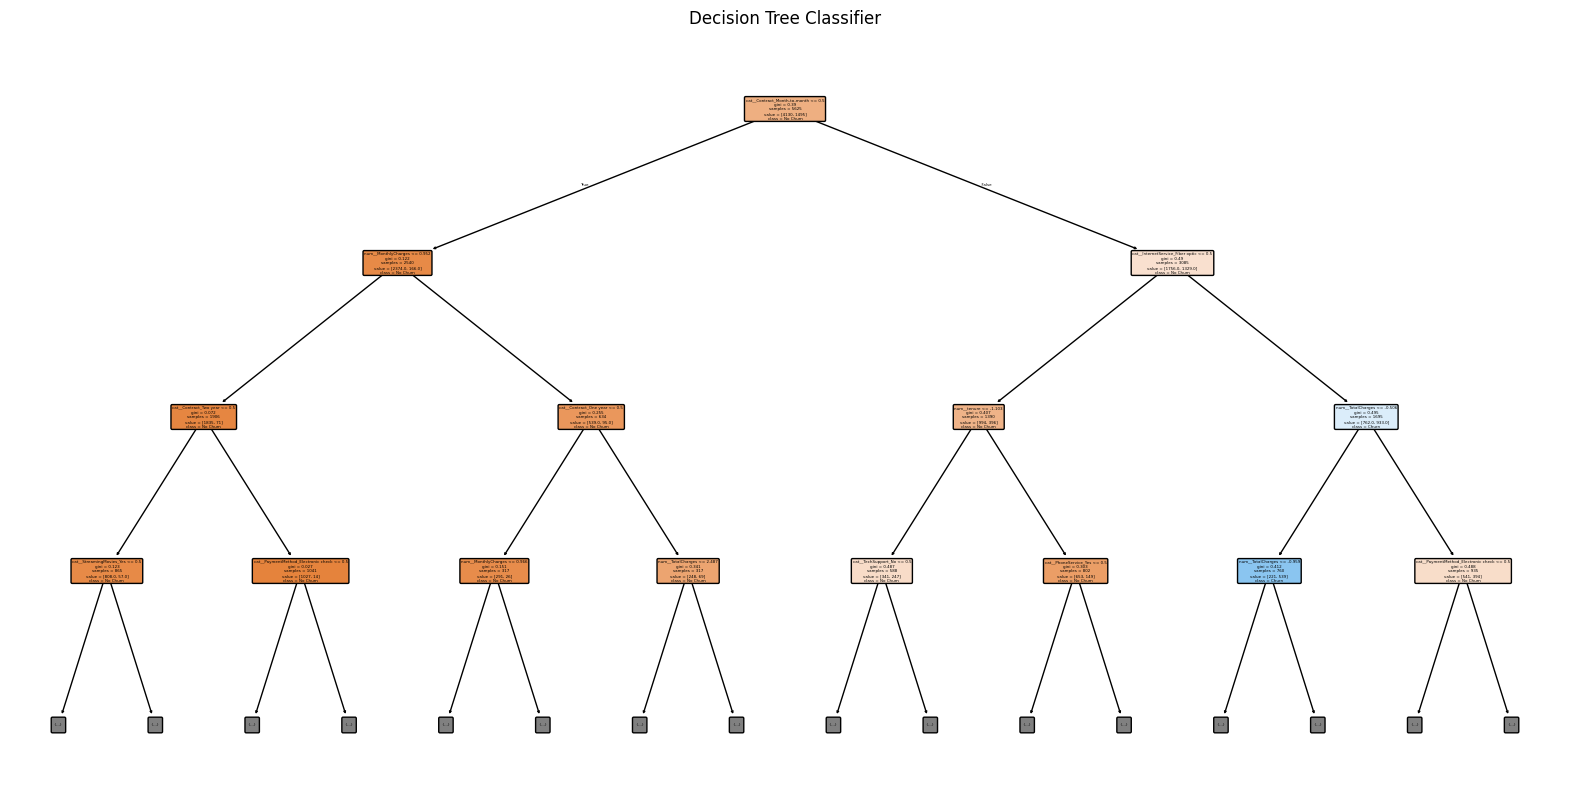

In [61]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classifier")
plt.show()

### Observation – Decision Tree Classifier

The Decision Tree Classifier was trained on the preprocessed training dataset and evaluated on the held-out test dataset. The model achieved an accuracy of 0.72.72 and a weighted F1-score of 0.7278.

The confusion matrix shows the correctly and incorrectly classified churn and non-churn customers. The decision tree visualization illustrates how the model makes classification decisions through a sequence of feature-based splits.

The baseline model uses the default tree configuration. The `max_depth` hyperparameter will be tuned later to control tree complexity and reduce the possibility of overfitting.

## 5. Support Vector Classifier (SVC)

Support Vector Classifier (SVC) is a supervised classification algorithm that finds an optimal decision boundary separating different classes.

SVC attempts to maximize the margin between the classes. It can also handle non-linear relationships using kernel functions.

For the baseline model, the default RBF (Radial Basis Function) kernel is used with the default regularization parameter `C = 1`. Hyperparameter tuning of `C` and the kernel will be performed later.

In [62]:
from sklearn.svm import SVC
svc_model = SVC(
    random_state=42
)
svc_model.fit(X_train_processed, y_train)
y_pred_svc = svc_model.predict(X_test_processed)
y_pred_svc[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

##### Accuracy

In [63]:
from sklearn.metrics import accuracy_score

svc_accuracy = accuracy_score(
    y_test,
    y_pred_svc
)

print(f"SVC Accuracy: {svc_accuracy:.4f}")

SVC Accuracy: 0.7925


##### Weighted F1-Score

In [64]:
from sklearn.metrics import f1_score

svc_f1 = f1_score(
    y_test,
    y_pred_svc,
    average='weighted'
)

print(f"SVC Weighted F1-score: {svc_f1:.4f}")

SVC Weighted F1-score: 0.7831


##### Confusion Matrix

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svc_cm = confusion_matrix(
    y_test,
    y_pred_svc
)

print("Confusion Matrix:")
print(svc_cm)

Confusion Matrix:
[[930 103]
 [189 185]]


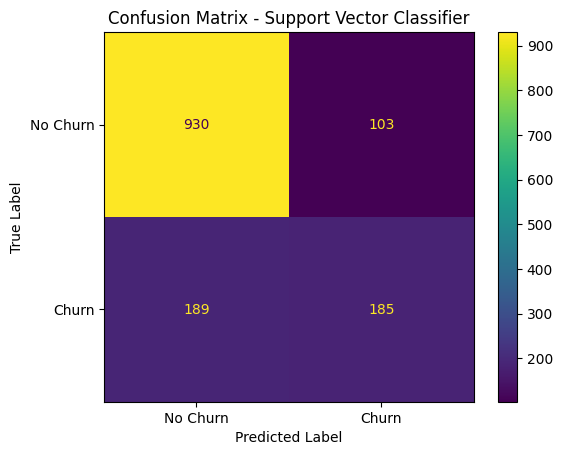

In [66]:
svc_display = ConfusionMatrixDisplay(
    confusion_matrix=svc_cm,
    display_labels=["No Churn", "Churn"]
)

svc_display.plot()

plt.title("Confusion Matrix - Support Vector Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [67]:
classification_results.append({
    "Algorithm": "Support Vector Classifier",
    "Accuracy": svc_accuracy,
    "Weighted F1": svc_f1
})

### Observation – Support Vector Classifier

The Support Vector Classifier was trained on the preprocessed training dataset and evaluated on the held-out test dataset. The model achieved an accuracy of 0.7925 and a weighted F1-score of 0.7831.

The confusion matrix shows the correctly and incorrectly classified churn and non-churn customers.

The baseline SVC uses the RBF kernel, which can model non-linear relationships between features. The `C` parameter and kernel type will be tuned later to identify a better-performing configuration.

In [68]:
comparison_df = pd.DataFrame(classification_results)

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df.index = comparison_df.index + 1

comparison_df

,Algorithm,Accuracy,Weighted F1
1,Logistic Regression,0.805259,0.801407
2,Support Vector Classifier,0.792466,0.783133
3,K-Nearest Neighbors,0.761905,0.763374
4,Decision Tree Classifier,0.739161,0.740563
5,Gaussian Naive Bayes,0.683724,0.702132
